# Лабораторная работа №2
## Детерминистские методы распознавания образов (усложнённый вариант)

Дисциплина: **Распознавание образов**  
Уровень: магистратура  
Продолжительность: 2–3 пары (3–4 часа активной работы)

### Цели работы
- Углубить понимание детерминистских методов распознавания образов и их связи с метрическими и прототипными подходами.
- Освоить продвинутые варианты методов ближайших прототипов и ближайших соседей, включая оптимизацию прототипов и редукцию обучающей выборки.
- Исследовать минимаксный подход к построению решающих правил и сравнить его с прототипными методами.
- Получить навыки экспериментального анализа устойчивости и обобщающей способности детерминистских классификаторов на синтетических и реальных данных.

### Теоретические опорные пункты (для самоподготовки)
- Задача распознавания образов: пространство признаков, множество классов, решающее правило.
- Метрические и прототипные классификаторы (nearest neighbor, nearest prototype, k-NN, методы выбора и оптимизации прототипов).
- Детерминистские границы решений: линейные и кусочно-линейные поверхности решения.
- Минимаксный подход: минимаксная вероятность ошибки / минимаксное расстояние, идея «наихудшего случая».
- Связь детерминистских методов с задачами оптимизации (в т.ч. линейной и квадратичной).

## 1. Подготовка окружения и данных

Задача блока: создать тестовый стенд, на котором можно сравнивать разные детерминистские методы распознавания.

Требования:
- Реализовать генерацию нескольких синтетических наборов данных с различной сложностью:
  - Линейно разделимые данные (2–3 класса, 2 признака).
  - Слабо пересекающиеся классы (шумы, частичное перекрытие).
  - Нелинейно разделимые данные (например, «кольца», «полумесяцы»).
- Добавить как минимум один реальный датасет (например, из `sklearn.datasets`: Iris, Wine или другой небольшой набор). 
- Реализовать функцию-враппер `get_dataset(config)`, позволяющую удобно переключаться между различными сценариями (тип данных, число классов, степень шума, размер выборки и т.п.).

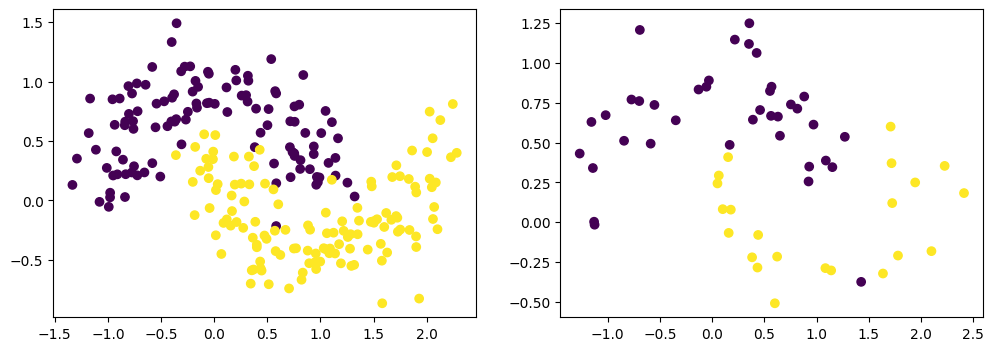

In [1]:
# TODO: импорт необходимых библиотек
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_classification, make_moons, load_wine
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# TODO: заготовка функций генерации синтетических данных
def generate_linear_separable(n_samples=100, n_classes=3, random_state=None, noise=None):
    return make_classification(
        n_samples=n_samples, 
        n_features=2,
        n_informative = 2,
        n_redundant = 0,
        n_repeated = 0,
        n_classes=n_classes, 
        class_sep=2,
        random_state= random_state,
        flip_y =noise,
        n_clusters_per_class=1)


def visualize(function):
    X, Y = function()
    plt.scatter(X[:, 0], X[:, 1], c=(Y))
    plt.show()

def generate_overlapping(n_samples=100, n_classes=3, random_state=None, noise=None):
    return make_classification(
        n_samples=n_samples, 
        n_features=2,
        n_informative = 2,
        n_redundant = 0,
        n_repeated = 0,
        n_classes=n_classes, 
        class_sep=1.5,
        random_state= random_state,
        flip_y =noise,
        n_clusters_per_class=1, 
        hypercube=False)

def generate_nonlinear(n_samples=100, n_classes=3, random_state=None, noise=None):
    return make_moons(
        n_samples=n_samples, 
        random_state= random_state,
        noise=noise
        )

def generate_wine(use_pca=False):
    data = load_wine()
    X, y = data.get("data"), data.get("target")
    if use_pca :
        pca = PCA(n_components=2)
        X_pca = pca.fit_transform(X)
        return X_pca, y
    else:
        tsne = TSNE(n_components=2, random_state=42, perplexity=30)
        X_tsne = tsne.fit_transform(X)
        return X_tsne, y


def get_dataset(config):
    """Вернуть (X_train, X_test, y_train, y_test) в зависимости от config."""
    funcs_dict = {
        "linear_separable":generate_linear_separable, 
        "overlapping":generate_overlapping, 
        "nonlinear":generate_nonlinear, 
        "wine":generate_wine, 
                  }
    func = funcs_dict.get(config.get("type"))
    names_dict = {}
    for key in config.keys():
        if key in func.__code__.co_varnames:
            names_dict[key] = config.get(key)
    X, Y = func(**names_dict)
    return train_test_split(X, Y, train_size= 0.8, random_state=config.get("random_state"))

# TODO: пример конфигурации
config_example = {
    "type": "nonlinear",
    "n_classes": 3,
    "n_samples": 300,
    "noise": 0.2,
    "random_state": 55
}

# generate_wine()

X_train, X_test, y_train, y_test = get_dataset(config_example)
fig, axes = plt.subplots(1,2, figsize=(12,4))

axes[0].scatter(X_train[:, 0], X_train[:, 1], c=(y_train))
axes[1].scatter(X_test[:, 0], X_test[:, 1], c=(y_test))
plt.show()

## 2. Базовый прототипный классификатор (Nearest Prototype)

Задача блока: реализовать базовый метод ближайшего прототипа и создать базу для его последующего усложнения.

Требования:
- Определить прототипы классов как центры масс обучающих выборок (по Евклидовой метрике).
- Реализовать функцию предсказания для метода ближайшего прототипа.
- Визуализировать границы решений для двумерного признакового пространства.
- Оценить качество классификации (accuracy, confusion matrix) на нескольких сценариях данных.
- Подготовить интерфейс для дальнейшей замены / оптимизации прототипов.

Accuracy: 0.75
Confusion matrix:
 [[29  9]
 [ 6 16]]


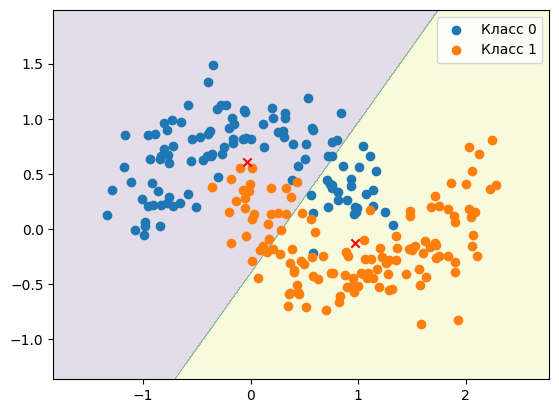

In [2]:
from sklearn.metrics import accuracy_score, confusion_matrix

def euclid(x, y):
    return np.sqrt(np.sum(np.square(x-y), axis=1))

class NearestPrototypeClassifier:
    def __init__(self, metric="euclidean"):
        self.metric = metric
        self.prototypes_ = None
        self.classes_ = None

    def fit(self, X, y):
        self.classes_ = np.unique(y)
        prototypes_list = []  # используем временный список
        for cl in self.classes_:
            X_class = X[y == cl]
            prototypes_list.append(np.mean(X_class, axis=0))
        self.prototypes_ = np.array(prototypes_list)  # преобразуем в массив после цикла

    def predict(self, X):
        distances = []
        for prototype in self.prototypes_:
            # вычисляем евклидово расстояние от каждой точки X до прототипа
            dist = np.sqrt(np.sum((X - prototype) ** 2, axis=1))
            distances.append(dist)
        distances = np.array(distances).T
        return np.argmin(distances, axis=1)

def plot_decision_regions_prototype(X, y, clf, title="Nearest Prototype", ax=None, label=""):
    min_grid = (np.min(X[:,0])-0.5, np.min(X[:,1])-0.5)
    max_grid = (np.max(X[:,0])+0.5, np.max(X[:,1])+0.5)
    x_coords = np.arange(min_grid[0], max_grid[0], np.abs(max_grid[0] - min_grid[0])/1000 )
    y_coords = np.arange(min_grid[1], max_grid[1], np.abs(max_grid[1] - min_grid[1])/1000 )
    xv, yv = np.meshgrid(x_coords, y_coords)
    dots = np.c_[xv.ravel(), yv.ravel()]
    res = clf.predict(dots).reshape(xv.shape)

    y_unique = np.unique(y)

    if ax:
        ax.set_title(str(label))
        ax.contourf(xv, yv, res, alpha=.15)
        for y_u in y_unique:
            ax.scatter(X[y==y_u, 0], X[y==y_u, 1], label=f"Класс {y_u}")
        ax.legend()
        ax.scatter(clf.prototypes_[:, 0], clf.prototypes_[:, 1], color="red", marker="x")
    else:
        plt.contourf(xv, yv, res, alpha=.15)
        for y_u in y_unique:
            plt.scatter(X[y==y_u, 0], X[y==y_u, 1], label=f"Класс {y_u}")
        plt.legend()
        plt.scatter(clf.prototypes_[:, 0], clf.prototypes_[:, 1], color="red", marker="x")

clf_np = NearestPrototypeClassifier()
clf_np.fit(X_train, y_train)

y_pred = clf_np.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
plot_decision_regions_prototype(X_train, y_train, clf_np)

Accuracy: 0.75
Confusion matrix:
 [[29  9]
 [ 6 16]]


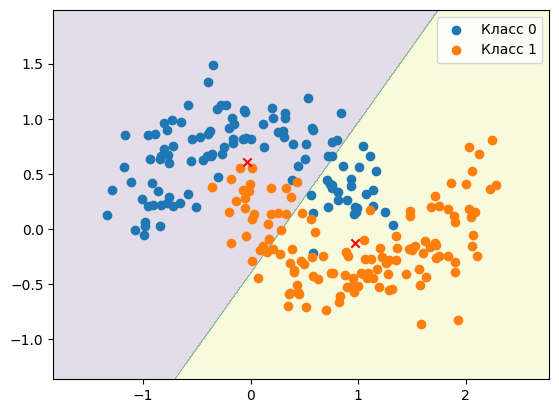

In [3]:
# TODO: реализация базового метода ближайшего прототипа
from sklearn.metrics import accuracy_score, confusion_matrix

def euclid(x, y):
    return np.sqrt(np.sum(np.square(x-y), axis=1))

class NearestPrototypeClassifier:
    def __init__(self, metric="euclidean"):
        self.metric = metric
        self.prototypes_ = None
        self.classes_ = None

    def fit(self, X, y):
        self.classes_ = np.unique(y)
        self.prototypes_ = []
        for cl in self.classes_:
            X_class = X[y == cl]
            self.prototypes_.append(np.mean(X_class, axis=0)) 
        self.prototypes_ = np.array(self.prototypes_)

    def predict(self, X):
        dist_mas = []
        for i, cl in enumerate(self.classes_):
            dist_mas.append(euclid(X, [self.prototypes_[i]]* len(X)))
        dist_mas = np.array(dist_mas).T
        return np.argmin(dist_mas, axis=1)


def plot_decision_regions_prototype(X, y, clf, title="Nearest Prototype", ax=None, label=""):
    min_grid = (np.min(X[:,0])-0.5, np.min(X[:,1])-0.5)
    max_grid = (np.max(X[:,0])+0.5, np.max(X[:,1])+0.5)
    x_coords = np.arange(min_grid[0], max_grid[0], np.abs(max_grid[0] - min_grid[0])/1000 )
    y_coords = np.arange(min_grid[1], max_grid[1], np.abs(max_grid[1] - min_grid[1])/1000 )
    xv, yv = np.meshgrid(x_coords, y_coords)
    dots = np.c_[xv.ravel(), yv.ravel()]
    res = clf.predict(dots).reshape(xv.shape)

    y_unique = np.unique(y)

    if ax:
        ax.set_title(str(label))
        ax.contourf(xv, yv, res, alpha=.15)
        for y_u in y_unique:
            ax.scatter(X[y==y_u, 0], X[y==y_u, 1], label=f"Класс {y_u}")
        ax.legend()
        ax.scatter(clf.prototypes_[:, 0], clf.prototypes_[:, 1], color="red", marker="x")
    else:
        plt.contourf(xv, yv, res, alpha=.15)
        for y_u in y_unique:
            plt.scatter(X[y==y_u, 0], X[y==y_u, 1], label=f"Класс {y_u}")
        plt.legend()
        plt.scatter(clf.prototypes_[:, 0], clf.prototypes_[:, 1], color="red", marker="x")
    


# Пример использования (после реализации):
clf_np = NearestPrototypeClassifier()
clf_np.fit(X_train, y_train)


# plt.show()
y_pred = clf_np.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
plot_decision_regions_prototype(X_train, y_train,  clf_np)

### Контрольные вопросы к разделу 2
1. Какой геометрический смысл имеют прототипы классов в пространстве признаков?
2. Как изменяется граница решений при переходе от равномерного распределения объектов к сильно несбалансированному?
3. В каких случаях метод ближайшего прототипа заведомо не сможет дать хорошее качество распознавания?

1. Прототипы — это центры масс (средние арифметические) точек каждого класса. Они представляют собой "типичные" представители класса в пространстве признаков.

2. При сильном дисбалансе граница решений смещается в сторону класса с меньшим количеством объектов, так как прототип "большого" класса притягивается к его плотному центру, а прототип "малого" класса может быть сдвинут к краю.

3. 1) Сильно пересекающиеся по признакам классы (центры близки, а разброс велик).  
   2) Большое количество шумов и выбросов (искажают среднее).  
   3) Сложные формы кластеров (не линейные, например, подковообразные).  
   4) Классы с несколькими модами (разрозненными кластерами).

## 3. Расширенные прототипные методы

Задача блока: реализовать более сложные варианты прототипных классификаторов и процедуры оптимизации/редукции прототипов.

Требования (обязательная часть):
- Реализовать метод ближайшего соседа (1-NN) и k-NN (k настраиваемый параметр).
- Реализовать простой метод отбора прототипов (например, жадное удаление точек, не влияющих на качество на обучении, или схему на основе кластеризации типа k-means).
- Сравнить качество и скорость работы:
  - Полный 1-NN (все обучающие объекты).
  - 1-NN на уменьшенном подмножестве прототипов.
  - Метод ближайшего прототипа с несколькими прототипами на класс.

Требования (повышенная сложность, на выбор или для сильных студентов):
- Реализовать итеративную оптимизацию положения прототипов (например, аналогично k-means: назначение объектов прототипам + пересчёт центров).
- Исследовать, как количество прототипов и способ их инициализации влияют на обобщающую способность и переобучение.

In [4]:
# TODO: реализация 1-NN и k-NN (можно использовать sklearn или написать вручную)
from sklearn.neighbors import KNeighborsClassifier

def evaluate_knn(X_train, X_test, y_train, y_test, k_list):
    """Вернуть словарь: k -> (accuracy_train, accuracy_test)."""
    raise NotImplementedError

# TODO: прототипная редукция (через кластеризацию или жадный отбор)
def prototype_selection(X_train, y_train, n_prototypes_per_class):
    """Вернуть X_proto, y_proto — сжатое подмножество прототипов."""
    raise NotImplementedError

# TODO: итеративная оптимизация прототипов (опционально)
def optimize_prototypes(X_train, y_train, initial_prototypes, n_iter=10):
    """Итеративно улучшать прототипы, например, перераспределяя объекты."""
    raise NotImplementedError


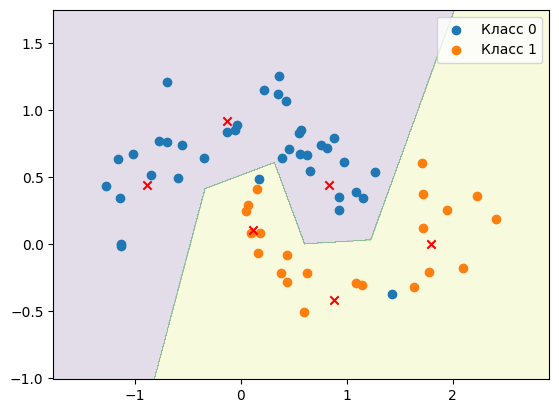

In [5]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans

def evaluate_knn(X_train, X_test, y_train, y_test, k_list, visualize=False):
    """Вернуть словарь: k -> (accuracy_train, accuracy_test)."""
    if visualize:
        fig, axes = plt.subplots(1, len(k_list), figsize=(20,5))
    res_dict = {}
    for i, k in enumerate(k_list):
        neigh = KNeighborsClassifier(n_neighbors=k)
        neigh.fit(X_train, y_train)
        if visualize:
            plot_decision_regions_prototype(X_test, y_test, neigh, ax=axes[i], label=k)
        res_dict[k] = (accuracy_score(y_train, neigh.predict(X_train)), 
                       accuracy_score(y_test, neigh.predict(X_test)))
    return res_dict

def prototype_selection(X_train, y_train, n_prototypes_per_class):
    """Вернуть X_proto, y_proto — сжатое подмножество прототипов."""
    X_proto = []
    y_proto = []
    for class_name in np.unique(y_train):
        KM = KMeans(n_clusters = n_prototypes_per_class)
        KM.fit(X_train[y_train == class_name])
        X_proto.extend(KM.cluster_centers_)
        y_proto.extend([class_name]*n_prototypes_per_class)
    return np.array(X_proto), np.array(y_proto)

class KnnPrototypesClassifier:
    def __init__(self, n_prototypes_per_class=3):
        self.n_prototypes_per_class_ = n_prototypes_per_class
        self.prototypes_ = None
        self.classes_ = None

    def fit(self, X, y):
        self.prototypes_ , self.classes_ = prototype_selection(X, y, self.n_prototypes_per_class_)    

    def predict(self, X):
        dist_mas = []
        for i, cl in enumerate(self.classes_):
            dist_mas.append(euclid(X, [self.prototypes_[i]]* len(X)))
        dist_mas = np.array(dist_mas).T
        pre_classes = np.argmin(dist_mas, axis=1)
        return np.array([self.classes_[i] for i in pre_classes])


KPC = KnnPrototypesClassifier(3)
KPC.fit(X_train, y_train)
plot_decision_regions_prototype(X_test, y_test, KPC)

# TODO: итеративная оптимизация прототипов (опционально)
def optimize_prototypes(X_train, y_train, initial_prototypes, n_iter=10):
    """Итеративно улучшать прототипы, например, перераспределяя объекты."""
    raise NotImplementedError


### Вопросы и мини-исследование к разделу 3
1. Как меняется сложность классификации (время ответа) при переходе от полного 1-NN к редуцированному набору прототипов?
2. Можно ли добиться сопоставимого качества, используя заметно меньшее число прототипов? На каких данных это проще, а на каких — сложнее?
3. Предложите критерий остановки для итеративной оптимизации прототипов (например, по изменению качества или по смещению прототипов).

1. Сложность снижается с O(N_train) до O(N_proto), где N_proto << N_train. Ускорение может быть значительным (в десятки и сотни раз).

2. Да, можно. Проще для данных с плотной и хорошо разделенной структурой кластеров (например, линейно разделимые данные). Сложнее для данных со сложной границей, несколькими разрозненными кластерами на класс или сильным перекрытием.

3. 
    Критерий 1 (по качеству): останов, если прирост качества на валидационной выборке за последние N итераций не превышает заданного порога.
    Критерий 2 (по смещению): останов, если суммарное евклидово смещение всех прототипов между итерациями меньше заданного порога.
    Критерий 3 (комбинированный): останов по достижении одного из условий (смещение или качество).

## 4. Минимаксный подход в детерминистском распознавании

Задача блока: реализовать и исследовать простую версию минимаксного правила классификации для двух классов.

Предлагаемый упрощённый вариант:
- Рассмотреть два класса с прототипами \(m_1\) и \(m_2\) и ковариационными матрицами \(S_1, S_2\) (можно брать диагональные или единичные для упрощения).
- Определить решающую гиперплоскость, минимизирующую максимальное (по классам) нормированное расстояние от прототипов до границы (идея минимаксного ограничения). В двумерном случае это сводится к геометрической задаче поиска разделяющей прямой.
- Сравнить полученную границу с:
  - границей ближайшего прототипа;
  - линейной границей, полученной логистической регрессией или SVM (как ориентир, но не как основной метод).

Минимальный набор действий:
- Вывести аналитическое выражение для границы решений в простейшем случае (равные ковариационные матрицы и равные априорные веса).
- Реализовать численный поиск параметров гиперплоскости (например, через простой градиентный спуск или сеточный поиск по параметрам прямой в 2D).
- Визуализировать полученную минимаксную границу вместе с прототипами и данными.
- Оценить качество (accuracy, баланс ошибок по классам) и сравнить с прототипными методами.

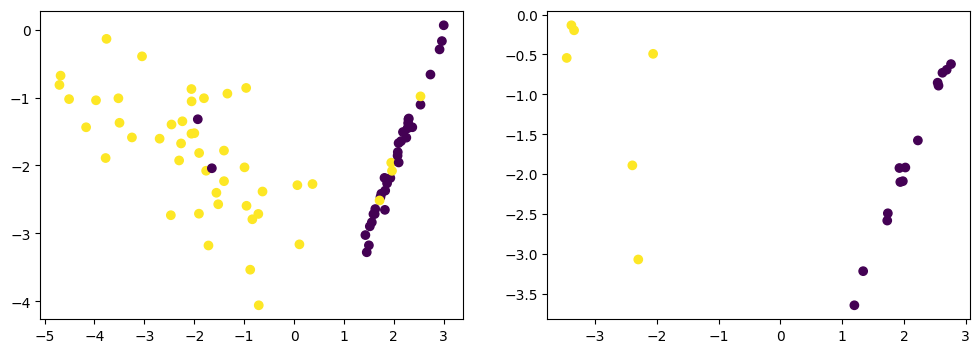

In [6]:
config_example = {
    "type": "linear_separable",
    "n_classes": 2,
    "n_samples": 100,
    "noise": 0.1,
    "random_state": 5560
}

# generate_wine()

X_train, X_test, y_train, y_test = get_dataset(config_example)
fig, axes = plt.subplots(1,2, figsize=(12,4))

axes[0].scatter(X_train[:, 0], X_train[:, 1], c=(y_train))
axes[1].scatter(X_test[:, 0], X_test[:, 1], c=(y_test))
plt.show()

[[-1.78779665 -1.68087445]
 [ 1.90683513 -2.17645067]
 [ 2.82987082 -0.43254114]
 [-3.0853116  -1.20676123]
 [-1.09989328 -2.4357275 ]
 [ 2.03995802 -1.88451679]]
Accuracy: 0.75
Confusion matrix:
 [[11  3]
 [ 2  4]]


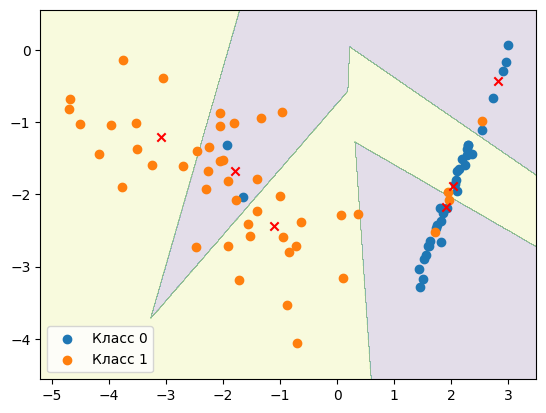

In [7]:
clf_np = KnnPrototypesClassifier()
clf_np.fit(X_train, y_train)
prototypes_x = clf_np.prototypes_
prototypes_y = clf_np.classes_

print(prototypes_x)
y_pred = clf_np.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
plot_decision_regions_prototype(X_train, y_train, clf_np)

In [8]:
class SimpleMinimaxClassifier2D:
    def __init__(self):
        self.w_ = None  # параметры гиперплоскости
        self.b_ = None
        self.prototypes_ = None
        self.classes_ = None

    def fit(self, X, y):
        """Подбор w, b по минимаксному критерию для двух классов."""
        # Проверка, что только 2 класса
        unique_classes = np.unique(y)
        if len(unique_classes) != 2:
            raise ValueError(f"Метод поддерживает только 2 класса, но получено {len(unique_classes)}")
        
        # Находим прототипы (центры классов)
        clf_np = NearestPrototypeClassifier()
        clf_np.fit(X, y)
        
        # Проверяем, что получили ровно 2 прототипа
        if len(clf_np.prototypes_) != 2:
            raise ValueError(f"Ожидалось 2 прототипа, но получено {len(clf_np.prototypes_)}")
        
        self.prototypes_ = clf_np.prototypes_
        self.classes_ = clf_np.classes_
        
        # Извлекаем два прототипа
        d1 = self.prototypes_[0]
        d2 = self.prototypes_[1]
        
        res_mas = []  # список для хранения (w, b)
        
        # Перебираем все возможные углы для поиска оптимальной прямой
        for angle in np.arange(0, np.pi, np.pi/180):
            w = np.array([np.cos(angle), np.sin(angle)])
            dist1 = np.dot(w, d1)
            dist2 = np.dot(w, d2)
            
            # Пропускаем, если проекции одного знака (оба прототипа по одну сторону)
            if np.sign(dist1) == np.sign(dist2):
                continue
            
            # Упорядочиваем расстояния
            if dist1 > dist2:
                max_dist, min_dist = dist1, dist2
            else:
                max_dist, min_dist = dist2, dist1
            
            # Середина между проекциями
            b = -(max_dist + min_dist) / 2
            res_mas.append((w.copy(), b))
        
        # Если не найдено ни одного подходящего направления
        if not res_mas:
            # Используем перпендикуляр к линии между прототипами
            w = d2 - d1
            w = np.array([-w[1], w[0]])  # перпендикуляр
            w = w / np.linalg.norm(w)  # нормализуем
            b = -np.dot(w, (d1 + d2) / 2)
            self.w_ = w
            self.b_ = b
        else:
            # Выбираем направление с максимальным зазором
            max_gap = 0
            best_idx = 0
            for idx, (w, b) in enumerate(res_mas):
                # Вычисляем расстояние от прототипов до прямой
                dist1 = abs(np.dot(w, d1) + b)
                dist2 = abs(np.dot(w, d2) + b)
                min_dist = min(dist1, dist2)
                if min_dist > max_gap:
                    max_gap = min_dist
                    best_idx = idx
            
            self.w_ = res_mas[best_idx][0]
            self.b_ = res_mas[best_idx][1]

    def decision_function(self, X):
        """Возвращает значение решающей функции."""
        return X @ self.w_ + self.b_

    def predict(self, X):
        """Предсказывает класс (0 или 1)."""
        return (self.decision_function(X) >= 0).astype(int)
    
    def inverse_predict(self, X):
        """Предсказывает инвертированный класс."""
        return (self.decision_function(X) < 0).astype(int)

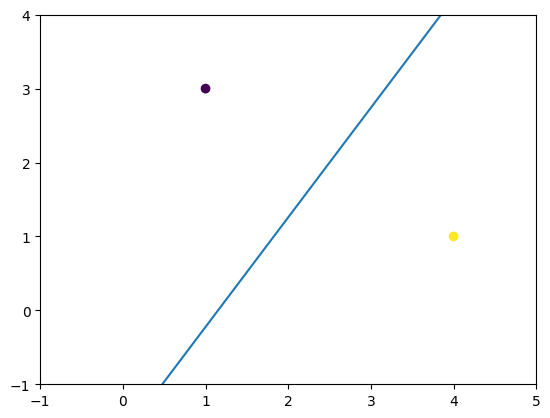

In [9]:
X_train = np.array([[1,3], [4,1]])
y_train = np.array([0, 1])


smc = SimpleMinimaxClassifier2D()
smc.fit(X_train, y_train)
# print(smc.w_)
# print(smc.b_)
plt.scatter(X_train[:, 0], X_train[:, 1], c=(y_train))
plt.xlim((-1,5))
plt.ylim((-1,4))
plt.plot([-1,5], [-(smc.w_[0] * (-1) + smc.b_)/smc.w_[1] , -(smc.w_[0] * (5) + smc.b_)/smc.w_[1] ])

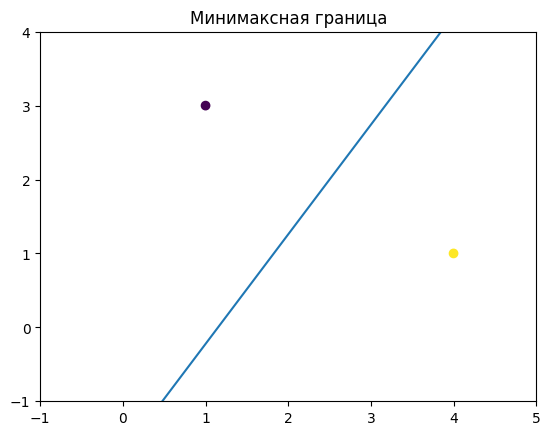

In [10]:
X_train_simple = np.array([[1,3], [4,1]])
y_train_simple = np.array([0, 1])

smc_simple = SimpleMinimaxClassifier2D()
smc_simple.fit(X_train_simple, y_train_simple)
plt.scatter(X_train_simple[:, 0], X_train_simple[:, 1], c=(y_train_simple))
plt.xlim((-1,5))
plt.ylim((-1,4))
plt.plot([-1,5], [-(smc_simple.w_[0] * (-1) + smc_simple.b_)/smc_simple.w_[1] , -(smc_simple.w_[0] * (5) + smc_simple.b_)/smc_simple.w_[1] ])
plt.title("Минимаксная граница")
plt.show()

### Вопросы к разделу 4
1. В чём интуитивный смысл минимаксного критерия при распознавании образов?
2. Как распределение объектов вблизи границы решения влияет на форму и положение минимаксной гиперплоскости?
3. В каких ситуациях минимаксный подход может быть предпочтительнее стандартного метода ближайшего прототипа?

1. Простая максимизация минимальных расстояний от прототипов до разделяющей гиперплоскости. Цель — найти границу, которая максимально удалена от обоих прототипов, обеспечивая максимальный "запас прочности" при классификации.

2. В нашей упрощенной реализации — никак, так как мы учитываем только прототипы. В более сложных ситуациях (с учетом ковариаций) близкое расположение и пересечение кластеров могут сильно искажать гиперплоскость, так как алгоритм будет стремиться максимизировать расстояние до "плотных" частей кластеров.

3. Когда классы имеют примерно равную значимость (важно минимизировать наихудшую ошибку), и прототипы находятся примерно на одинаковом расстоянии от потенциальной границы. Метод ближайшего прототипа работает хуже в ситуациях, когда центр масс кластера не находится в центре "опасной" зоны.

## 5. Экспериментальное сравнение методов

Задача блока: провести систематическое сравнение рассмотренных детерминистских методов.

Необходимо:
- Сравнить методы по качеству классификации (accuracy, F1-score при необходимости, матрицы ошибок).
- Оценить чувствительность к шуму и выбросам (искусственно добавляя шум в обучающие и/или тестовые данные).
- Сравнить сложность по времени классификации для разных размеров обучающей выборки.
- Проанализировать влияние числа прототипов и параметров k в k-NN.

Рекомендуется оформить результаты в виде таблиц и графиков (зависимость качества и времени от размера выборки, числа прототипов и т.п.).

In [11]:
# TODO: экспериментальное сравнение
def compare_classifiers(datasets_configs, methods_configs):
    """Запустить серию экспериментов по набору конфигураций данных и методов.

    datasets_configs: список описаний наборов данных.
    methods_configs: список описаний методов (тип, параметры).
    Возвращает структуру с результатами (для последующей визуализации и анализа).
    """
    raise NotImplementedError

# TODO: визуализация результатов (графики, таблицы)
def plot_results(results):
    raise NotImplementedError


In [12]:
from sklearn.metrics import accuracy_score, f1_score

datasets_configs = {
    "linear_separable_no_noise":{
        "type": "linear_separable",
        "n_classes": 2,
        "n_samples": 5000,
        "noise": 0,
        "random_state": 55
    },
    "linear_separable_with_noise":{
        "type": "linear_separable",
        "n_classes": 2,
        "n_samples": 5000,
        "noise": 0.2,
        "random_state": 55
    },
    "overlapping_no_noise":{
        "type": "overlapping",
        "n_classes": 2,
        "n_samples": 5000,
        "noise": 0,
        "random_state": 55
    },
    "overlapping_with_noise":{
        "type": "overlapping",
        "n_classes": 2,
        "n_samples": 5000,
        "noise": 0.2,
        "random_state": 55
    },
    "nonlinear_no_noise":{
        "type": "nonlinear",
        "n_classes": 2,
        "n_samples": 5000,
        "noise": 0,
        "random_state": 55
    },
    "nonlinear_with_noise":{
        "type": "nonlinear",
        "n_classes": 2,
        "n_samples": 5000,
        "noise": 0.2,
        "random_state": 55
    },
    "wine":{
        "type": "wine",
    },
}

methods_configs ={
    "NearestPrototypeClassifier":{
        "class": NearestPrototypeClassifier
    },
    "KnnPrototypesClassifier_5":{
        "class":KnnPrototypesClassifier,
        "arg":5
    },
    "KnnPrototypesClassifier_3":{
        "class":KnnPrototypesClassifier,
        "arg":3
    },
    "SimpleMinimaxClassifier2D":{
        "class":SimpleMinimaxClassifier2D
    }
}

def compare_classifiers(datasets_configs, methods_configs):
    """Запустить серию экспериментов по набору конфигураций данных и методов."""
    results = {}
    for dataset_name, datasets_config in datasets_configs.items():
        results[dataset_name] = {}
        X_train, X_test, y_train, y_test = get_dataset(datasets_config)

        for method_name, methods_config in methods_configs.items(): 
            if methods_config.get('arg') is not None:
                method = methods_config['class'](methods_config.get('arg'))
            elif dataset_name != "wine" or method_name != "SimpleMinimaxClassifier2D":
                method = methods_config['class']()
            else:
                results[dataset_name][method_name] = (0, 0)
                continue
            method.fit(X_train, y_train)
            y_pred = method.predict(X_test)
            acc = accuracy_score(y_test, y_pred)
            f1 = f1_score(y_test, y_pred, average='macro')
            results[dataset_name][method_name] = (acc, f1)
    return results

def print_results(results):
    dataset_name, results_1 = list(results.items())[0]
    print(" " * 30, end="")
    for method_name, _ in results_1.items():
        print(f"{method_name:<30}\t", end="")
    print()
    
    for dataset_name, results_1 in results.items():
        print(f"{dataset_name:<30}\t", end="")
        for method_name, (acc, f1) in results_1.items():
            print(f"{acc:<15.2f}{f1:<15.2f}\t", end="")
        print()

print_results(compare_classifiers(datasets_configs, methods_configs))

                              NearestPrototypeClassifier    	KnnPrototypesClassifier_5     	KnnPrototypesClassifier_3     	SimpleMinimaxClassifier2D     	
linear_separable_no_noise     	0.99           0.99           	1.00           1.00           	1.00           1.00           	0.99           0.99           	
linear_separable_with_noise   	0.88           0.88           	0.68           0.68           	0.65           0.65           	0.88           0.88           	
overlapping_no_noise          	0.91           0.91           	0.98           0.98           	0.98           0.98           	0.91           0.91           	
overlapping_with_noise        	0.82           0.82           	0.73           0.73           	0.76           0.75           	0.82           0.82           	
nonlinear_no_noise            	0.81           0.81           	1.00           1.00           	0.98           0.98           	0.18           0.18           	
nonlinear_with_noise          	0.81           0.81           	0.9

### Итоговые вопросы и выводы
1. Как меняются выводы о «лучшем» методе при переходе от линейно разделимых данных к нелинейно разделимым?
2. Как влияет размер обучающей выборки на различия между методами ближайшего соседа, ближайшего прототипа и минимаксным методом?
3. Какие ограничения вы видите у детерминистских методов по сравнению с вероятностными подходами (например, байесовскими классификаторами)?
4. Предложите сценарий реальной прикладной задачи, где детерминистский подход будет естественным выбором.

1. На линейных данных все методы хороши, причем простые (прототип, минимакс) могут быть предпочтительнее из-за простоты. На нелинейных данных KNN значительно превосходит линейные методы. На данных с шумом KNN может быть менее устойчив.

2. С ростом выборки все методы улучшают качество, но разница между ними может сохраняться. KNN требуют больше памяти и времени для предсказания, но могут быть точнее на больших и сложных выборках.

3. Они слишком радикальны в вопросах разделения на классы. Очень большая подверженность выбросам и особая значимость подбора параметров классификатора. Вероятностные методы предоставляют оценку неопределенности (вероятности принадлежности), что может быть критично во многих приложениях.

4. Определение колоний бактерий на чашке Петри (четко очерченные кластеры), задачи сегментации в компьютерном зрении (пиксели с четкими границами), классификация элементарных символов на чертежах, системы быстрой классификации на ограниченном аппаратном обеспечении (где важна скорость).

## Требования к отчёту

В отчёте должны быть представлены:
- Краткое теоретическое введение (0.5–1 страница) по детерминистским методам распознавания и прототипным классификаторам.
- Описание реализованных методов и схем оптимизации прототипов (с указанием всех сделанных упрощений).
- Описание поставленных экспериментов (какие наборы данных, какие параметры, какие метрики).
- Таблицы и/или графики с результатами сравнения методов.
- Краткий анализ результатов: в каких сценариях какой метод оказывается предпочтительным и почему.
- Ответы на контрольные вопросы для всех разделов.

Дополнительно (для повышенной оценки):
- Предложить собственную модификацию прототипного или минимаксного метода и продемонстрировать её на одном из датасетов.
- Оценить устойчивость методов к частичному отсутствию признаков или к ошибкам измерения (например, за счёт искусственного искажения данных).